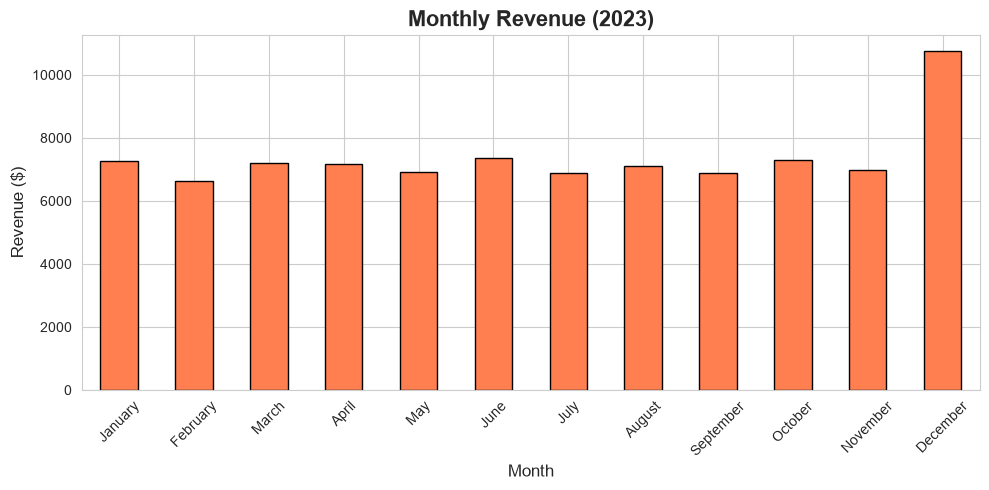

In [8]:
import pandas as pd 
import numpy as np 
import plt
import matplotlib.pyplot as plt
import seaborn as sns

cafe_data=pd.read_csv('cafe_sales_cleaned.csv')
# Group by month (correctly ordered)
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = cafe_data.groupby('month')['total_spent'].sum().reindex(month_order)
#? REVENUE BY MONTH
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Monthly Revenue (2023)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

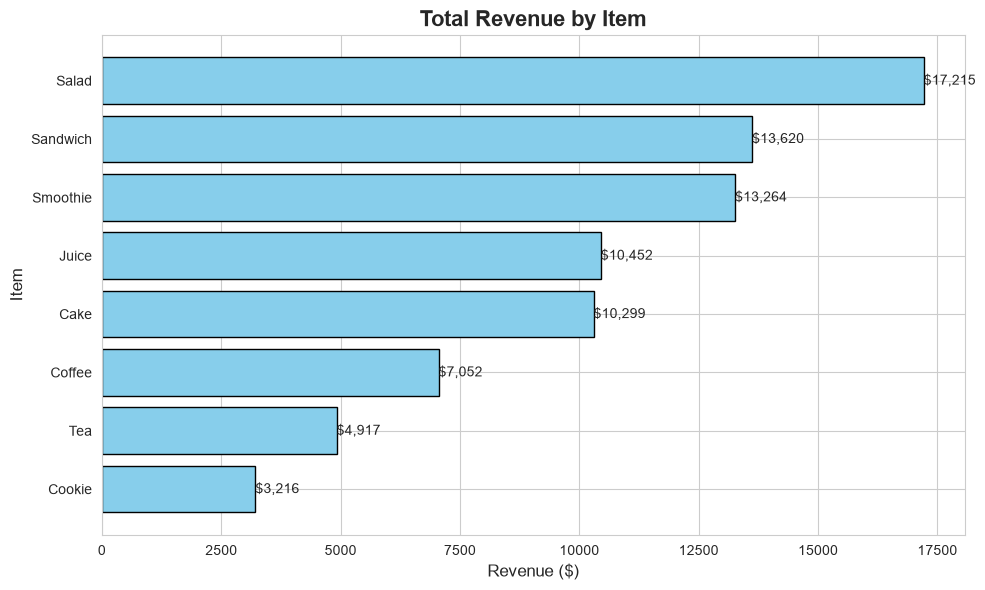

In [12]:
 #* Revenue by Item (excluding Unknown)
sns.set_style("whitegrid")
# Filter out Unknown THEN aggregate
item_revenue = cafe_data[cafe_data['item'] != 'UNKNOWN'].groupby('item')['total_spent'].sum().sort_values(ascending=True)
#  Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(item_revenue.index, item_revenue.values,color='skyblue', edgecolor='black')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'${width:,.0f}', va='center', fontsize=10)

plt.title('Total Revenue by Item', fontsize=16, fontweight='bold')
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('Item', fontsize=12)
plt.tight_layout()
plt.show()

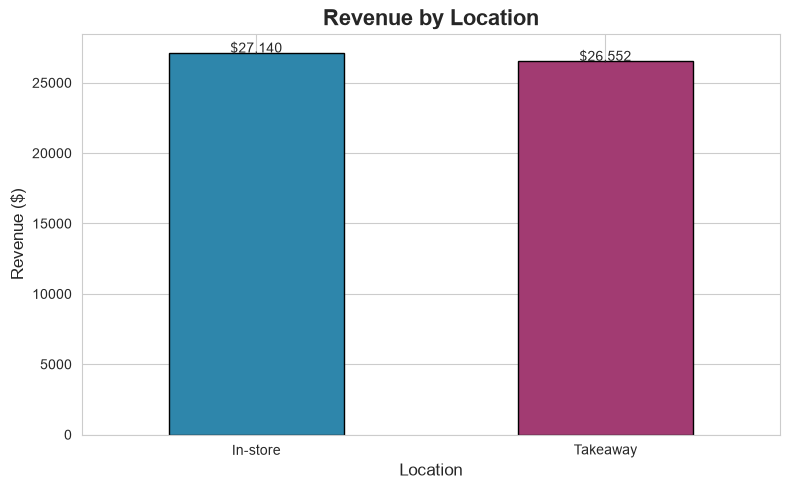

In [15]:
location_revenue = cafe_data[cafe_data['location'] != 'UNKNOWN'].groupby('location')['total_spent'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
colors = ['#2E86AB', '#A23B72', '#F18F01']  # custom colors
location_revenue.plot(kind='bar', color=colors, edgecolor='black')

#* Add value labels on top of bars
for i, v in enumerate(location_revenue.values):
    plt.text(i, v + 5, f'${v:,.0f}', ha='center', fontsize=10)

plt.title('Revenue by Location', fontsize=16, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\Irfan Awan\AppData\Local\Temp\ipykernel_38452\2001734774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_type', y='total_spent', data=plot_data, palette=['#3498db', '#e67e22'])


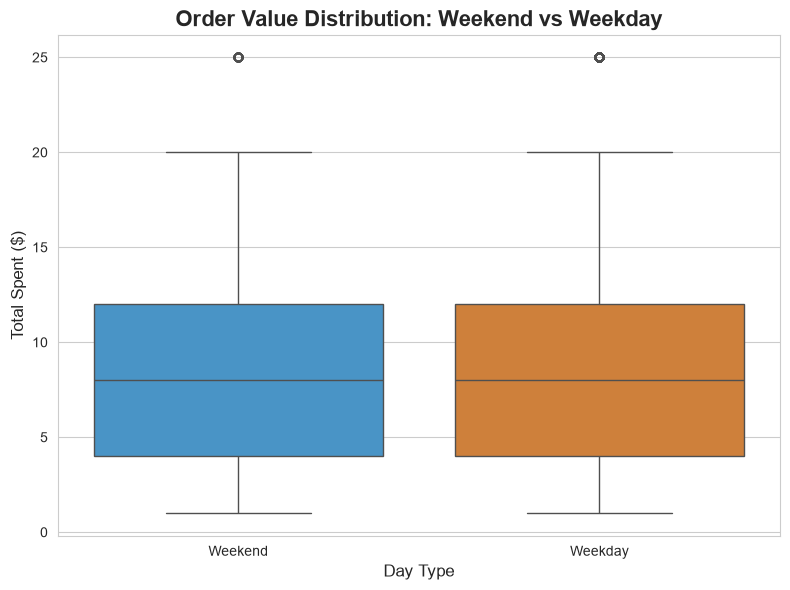

In [11]:
#?WEEKDAY SALES VS WEEKEND SALES
# 1. Create a clean copy with readable labels
plot_data = cafe_data.copy()
plot_data['day_type'] = plot_data['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# 2. Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='day_type', y='total_spent', data=plot_data, palette=['#3498db', '#e67e22'])

# 3. Add swarmplot to see individual points (optional, can be slow for many rows)
# sns.swarmplot(x='day_type', y='total_spent', data=plot_data, color='black', alpha=0.3, size=2)

plt.title('Order Value Distribution: Weekend vs Weekday', fontsize=16, fontweight='bold')
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Total Spent ($)', fontsize=12)
plt.tight_layout()
plt.show()

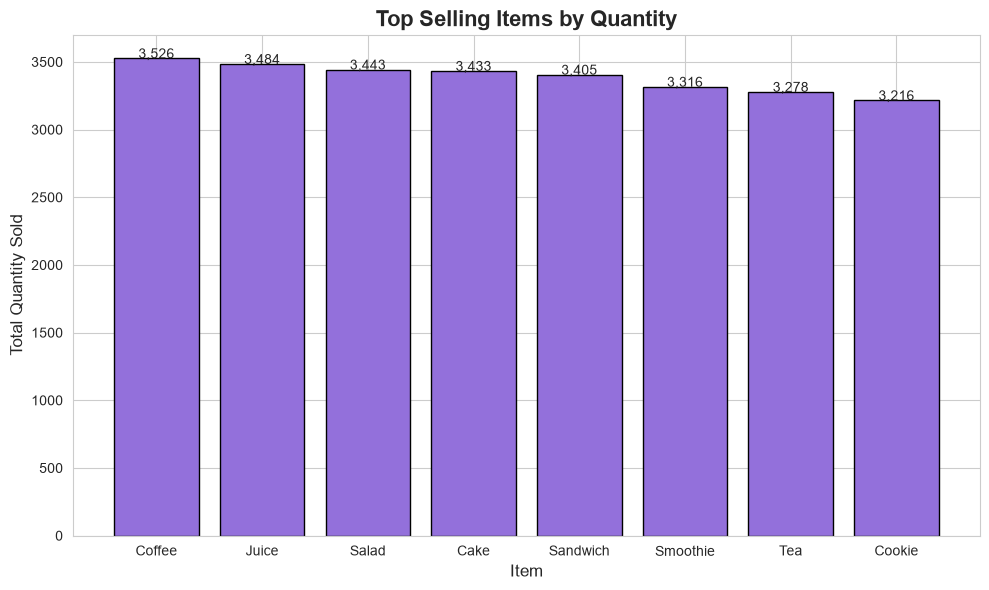

In [17]:
#* Top Selling Items by Quantity Sold

item_quantity = cafe_data[cafe_data['item'] != 'UNKNOWN'].groupby('item')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(item_quantity.index, item_quantity.values,  color='mediumpurple', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{int(height):,}', ha='center', fontsize=10)

plt.title('Top Selling Items by Quantity', fontsize=16, fontweight='bold')
plt.xlabel('Item', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.tight_layout()
plt.show()

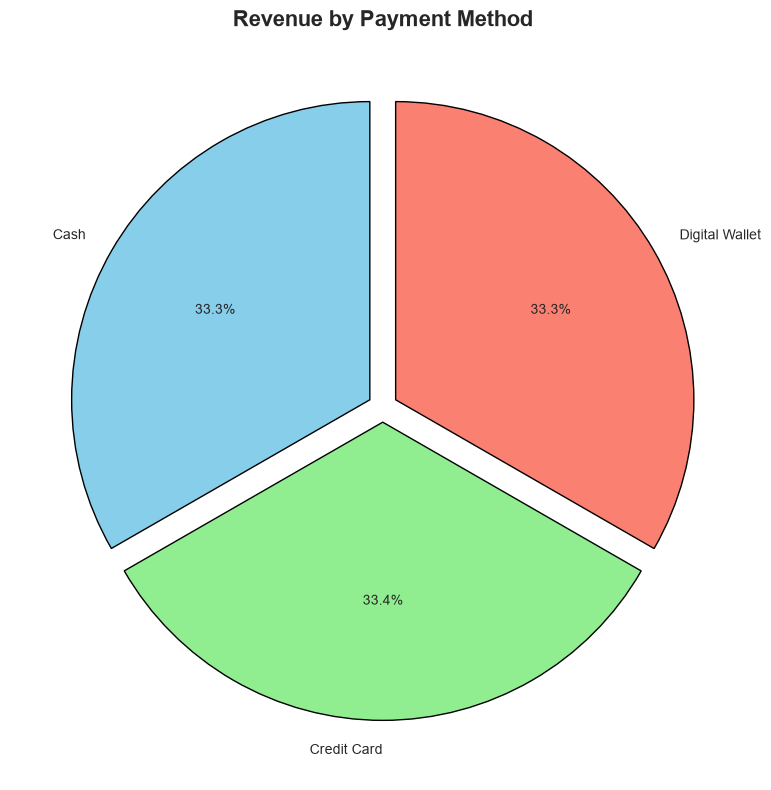

In [23]:
#* Payment Method Distribution

sns.set_style("whitegrid")
payment_data = cafe_data[cafe_data['payment_method'] != 'UNKNOWN'].groupby('payment_method')['total_spent'].sum()
# Plot
plt.figure(figsize=(8, 8))
plt.pie(payment_data.values,labels=payment_data.index,autopct='%1.1f%%',colors=['skyblue', 'lightgreen', 'salmon'],
explode=[0.05, 0.05, 0.05],startangle=90,wedgeprops={'edgecolor': 'black', 'linewidth': 1})

plt.title('Revenue by Payment Method', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()